In [3]:
# =========================
# 1. Install Dependencies
# =========================
!pip install -q transformers datasets peft accelerate evaluate rouge_score

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.4 MB/s eta 0:00:00


In [4]:
# =========================
# 2. Imports
# =========================
import torch
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    Trainer,
    TrainingArguments
)
from peft import LoraConfig, get_peft_model
import evaluate
import numpy as np

In [5]:
# =========================
# 3. Mount Drive
# =========================
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# =========================
# 4. Device Info
# =========================
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [7]:
# =========================
# 5. Config
# =========================
MODEL_NAME = "Qwen/Qwen2.5-0.5B"
OUTPUT_DIR = "/content/drive/MyDrive/alpaca_lora_model"

MAX_LEN = 256
EPOCHS = 10
TRAIN_SAMPLES = 8000
VAL_SAMPLES = 2000
TEST_SAMPLES = 2000

In [8]:
# =========================
# 6. Load Dataset
# =========================
dataset = load_dataset("tatsu-lab/alpaca")

dataset = dataset["train"].shuffle(seed=42)

train_ds = dataset.select(range(TRAIN_SAMPLES))
val_ds = dataset.select(range(TRAIN_SAMPLES, TRAIN_SAMPLES + VAL_SAMPLES))
test_ds = dataset.select(range(TRAIN_SAMPLES + VAL_SAMPLES, TRAIN_SAMPLES + VAL_SAMPLES + TEST_SAMPLES))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-a09b74b3ef9c3b(…):   0%|          | 0.00/24.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/52002 [00:00<?, ? examples/s]

In [9]:
# =========================
# 7. Display Dataset
# =========================
print("\nSample Dataset:\n")
for i in range(3):
    print(train_ds[i])
    print("-" * 50)


Sample Dataset:

{'instruction': 'What would be the best type of exercise for a person who has arthritis?', 'input': '', 'output': 'For someone with arthritis, the best type of exercise would be low-impact activities like yoga, swimming, or walking. These exercises provide the benefits of exercise without exacerbating the symptoms of arthritis.', 'text': 'Below is an instruction that describes a task. Write a response that appropriately completes the request.\n\n### Instruction:\nWhat would be the best type of exercise for a person who has arthritis?\n\n### Response:\nFor someone with arthritis, the best type of exercise would be low-impact activities like yoga, swimming, or walking. These exercises provide the benefits of exercise without exacerbating the symptoms of arthritis.'}
--------------------------------------------------
{'instruction': 'Calculate the atomic mass for lithium.', 'input': '', 'output': 'The atomic mass for lithium is 6.941 u (units). This is determined from th

In [10]:
# =========================
# 8. Prompt Formatting
# =========================
def build_prompt(example):
    instruction = example["instruction"]
    input_text = example["input"]
    output = example["output"]

    prompt = f"""### Instruction:
{instruction}

### Input:
{input_text}

### Response:
{output}"""

    return {"text": prompt}

train_ds = train_ds.map(build_prompt)
val_ds = val_ds.map(build_prompt)
test_ds = test_ds.map(build_prompt)

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [12]:
# =========================
# 9. Tokenizer
# =========================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token

def tokenize(example):
    enc = tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LEN
    )
    enc["labels"] = enc["input_ids"].copy()
    return enc

train_ds = train_ds.map(tokenize, remove_columns=train_ds.column_names)
val_ds = val_ds.map(tokenize, remove_columns=val_ds.column_names)
test_ds = test_ds.map(tokenize, remove_columns=test_ds.column_names)

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [13]:
# =========================
# 10. Load Model
# =========================
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto"
)

model.config.pad_token_id = tokenizer.eos_token_id
model.gradient_checkpointing_enable()

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

In [14]:
# =========================
# 11. LoRA Config
# =========================
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)

In [18]:
# =========================
# 12. Metrics
# =========================
bleu = evaluate.load("bleu")
rouge = evaluate.load("rouge")

def evaluate_model(model, dataset, num_samples=100):
    model.eval()
    predictions = []
    references = []

    for i in range(num_samples):
        input_ids = torch.tensor(dataset[i]["input_ids"]).unsqueeze(0).to(model.device)
        attention_mask = torch.tensor(dataset[i]["attention_mask"]).unsqueeze(0).to(model.device)

        with torch.no_grad():
            output = model.generate(
    input_ids,
    attention_mask=attention_mask,
    max_new_tokens=50,
    do_sample=True,
    pad_token_id=tokenizer.eos_token_id
)

        pred = tokenizer.decode(output[0], skip_special_tokens=True)
        ref = tokenizer.decode(dataset[i]["labels"], skip_special_tokens=True)

        predictions.append(pred)
        references.append(ref)

    bleu_score = bleu.compute(predictions=predictions, references=[[r] for r in references])
    rouge_score = rouge.compute(predictions=predictions, references=references)

    return bleu_score, rouge_score

In [19]:
# =========================
# 13. Evaluation BEFORE Training
# =========================
print("\nEvaluating BEFORE training...\n")
bleu_before, rouge_before = evaluate_model(model, test_ds)

print("BLEU BEFORE:", bleu_before)
print("ROUGE BEFORE:", rouge_before)


Evaluating BEFORE training...

BLEU BEFORE: {'bleu': 0.7116039963639194, 'precisions': [0.7154924671253157, 0.7129052095229729, 0.7103607196667553, 0.7076813019762139], 'brevity_penalty': 1.0, 'length_ratio': 1.395600388915897, 'translation_length': 11483, 'reference_length': 8228}
ROUGE BEFORE: {'rouge1': np.float64(0.7768397547549668), 'rouge2': np.float64(0.7709216351812715), 'rougeL': np.float64(0.7760647774729468), 'rougeLsum': np.float64(0.7767571589305413)}


In [20]:
# =========================
# 14. Training Args
# =========================
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=4,
    num_train_epochs=EPOCHS,
    learning_rate=2e-4,
    fp16=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    report_to="none"
)

In [21]:
# =========================
# 15. Trainer
# =========================
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds
)

In [22]:
# =========================
# 16. Train
# =========================
trainer.train()

Epoch,Training Loss,Validation Loss
1,0.485790,0.483984
2,0.466157,0.484632
3,0.443564,0.492504
4,0.393496,0.504537


Epoch,Training Loss,Validation Loss
1,0.485790,0.483984
2,0.466157,0.484632
3,0.443564,0.492504
4,0.393496,0.504537
5,0.388714,0.519080
6,0.388810,0.538407
7,0.336073,0.558029
8,0.326657,0.575993
9,0.333287,0.592164
10,0.305106,0.604371


TrainOutput(global_step=10000, training_loss=0.3923059931755066, metrics={'train_runtime': 12604.0606, 'train_samples_per_second': 6.347, 'train_steps_per_second': 0.793, 'total_flos': 4.4244271104e+16, 'train_loss': 0.3923059931755066, 'epoch': 10.0})

In [23]:
# =========================
# 17. Save Model
# =========================
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

('/content/drive/MyDrive/alpaca_lora_model/tokenizer_config.json',
 '/content/drive/MyDrive/alpaca_lora_model/chat_template.jinja',
 '/content/drive/MyDrive/alpaca_lora_model/tokenizer.json')

In [24]:
# =========================
# 18. Evaluation AFTER Training
# =========================
print("\nEvaluating AFTER training...\n")
bleu_after, rouge_after = evaluate_model(model, test_ds)

print("BLEU AFTER:", bleu_after)
print("ROUGE AFTER:", rouge_after)


Evaluating AFTER training...

BLEU AFTER: {'bleu': 0.7846552463122104, 'precisions': [0.7879746835443038, 0.7857281177381874, 0.7835353930387172, 0.7813981042654028], 'brevity_penalty': 1.0, 'length_ratio': 1.267379679144385, 'translation_length': 10428, 'reference_length': 8228}
ROUGE AFTER: {'rouge1': np.float64(0.8383928379365653), 'rouge2': np.float64(0.8329328670206841), 'rougeL': np.float64(0.8382302695442514), 'rougeLsum': np.float64(0.8386744267351897)}


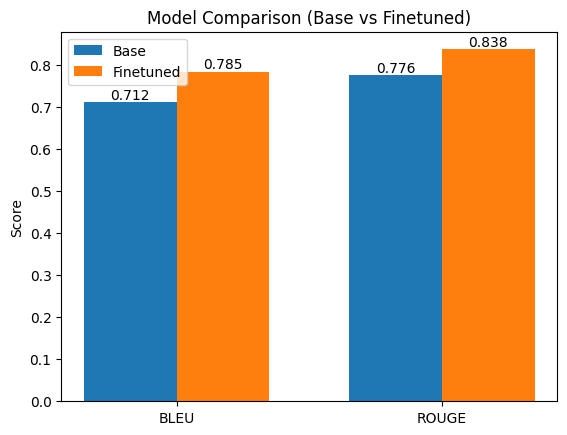

In [25]:
# =========================
# 19. BLEU & ROUGE BAR CHART
# =========================
import matplotlib.pyplot as plt
import numpy as np

# Extract values
bleu_b = bleu_before["bleu"]
bleu_a = bleu_after["bleu"]

rouge_b = rouge_before["rougeL"]
rouge_a = rouge_after["rougeL"]

metrics = ["BLEU", "ROUGE"]
before_scores = [bleu_b, rouge_b]
after_scores = [bleu_a, rouge_a]

x = np.arange(len(metrics))
width = 0.35

plt.figure()

bars1 = plt.bar(x - width/2, before_scores, width, label="Base")
bars2 = plt.bar(x + width/2, after_scores, width, label="Finetuned")

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Model Comparison (Base vs Finetuned)")
plt.legend()

# Add value labels on top
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f"{height:.3f}", ha='center', va='bottom')

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f"{height:.3f}", ha='center', va='bottom')

plt.show()

In [28]:
# =========================
# 19. Inference Test
# =========================
model.eval()

test_prompts = [
    """### Instruction:
What are the benefits of eating a healthy diet?

### Input:

### Response:
""",
    """### Instruction:
Explain the concept of quantum entanglement in simple terms.

### Input:

### Response:
""",
    """### Instruction:
Write a short story about a detective solving a mystery in a futuristic city.

### Input:

### Response:
""",
    """### Instruction:
List three common programming languages and their primary uses.

### Input:

### Response:
"""
]

for i, prompt in enumerate(test_prompts):
    print(f"\n--- Inference Test {i+1} ---")
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    output = model.generate(
        **inputs,
        max_new_tokens=100,
        pad_token_id=tokenizer.eos_token_id
    )

    print("\nGenerated Output:\n")
    print(tokenizer.decode(output[0], skip_special_tokens=True))



--- Inference Test 1 ---

Generated Output:

### Instruction:
What are the benefits of eating a healthy diet?

### Input:

### Response:
Eating a healthy diet can provide numerous benefits, including improved health, increased energy levels, better digestion, and better overall well-being. Eating a healthy diet can also help to reduce the risk of chronic diseases such as heart disease, diabetes, and certain types of cancer. Additionally, a healthy diet can help to improve mood and reduce stress levels.

--- Inference Test 2 ---

Generated Output:

### Instruction:
Explain the concept of quantum entanglement in simple terms.

### Input:

### Response:
Quantum entanglement is a phenomenon in which two or more particles become linked in such a way that the state of one particle is dependent on the state of the other. This means that the state of one particle can be used to predict the state of the other, even if they are separated by a large distance. This phenomenon is thought to be a f